# Do anúncio à estimativa  
## Projeto end-to-end de preços de imóveis com reamostragem, seleção e regularização

**Problema prático:** estimar o preço de venda de imóveis residenciais em Ames, Iowa, antes da negociação.

Este notebook combina quatro perspectivas:

1. **Capítulo 5 do ISLP:** conjunto de validação, validação cruzada, LOOCV e bootstrap.
2. **Capítulo 6 do ISLP:** seleção de subconjuntos, seleção forward, ridge, lasso, PCR e PLS.
3. **Scikit-learn MOOC:** pipelines, pré-processamento sem vazamento e avaliação da generalização.
4. **Hands-On Machine Learning:** fluxo end-to-end orientado ao problema, desde o enquadramento até a análise final dos erros.

O notebook foi escrito para estudo. Cada etapa contém:

- objetivo estatístico;
- código;
- interpretação esperada;
- perguntas de aprendizagem;
- alertas sobre decisões que podem gerar vazamento ou conclusões frágeis.

> **Escopo:** o modelo é educacional. O conjunto Ames registra um mercado, período e contexto específicos. Ele não deve ser usado como avaliador imobiliário atual sem nova coleta, validação temporal, análise jurídica e conhecimento local.

## Mapa do projeto

1. Formular o problema e definir a métrica.
2. Carregar e auditar os dados.
3. Separar o teste antes da exploração.
4. Explorar apenas o conjunto de treinamento.
5. Criar um baseline.
6. Construir o pipeline de pré-processamento.
7. Estudar a variabilidade de uma única divisão.
8. Comparar holdout, $k$-fold, LOOCV e validação repetida.
9. Fazer seleção forward e discutir a regra de um erro-padrão.
10. Ajustar ridge, lasso e elastic net.
11. Comparar PCR e PLS.
12. Usar bootstrap para medir estabilidade.
13. Executar validação cruzada aninhada.
14. Avaliar o modelo final uma única vez no teste.
15. Analisar erros, coeficientes e limitações.

## Como usar

Execute as células em ordem.

O modo rápido reduz grades, repetições e replicações bootstrap. Ele mantém a lógica do projeto, mas produz estimativas menos estáveis. Para uma análise final, use:

```python
FAST_MODE = False
```

A primeira execução baixa o conjunto Ames pelo OpenML e salva um cache local. As próximas execuções podem usar esse arquivo.

# 1. Ambiente e reprodutibilidade

O objetivo desta etapa é fixar sementes, controlar custo computacional e registrar versões. Um resultado reproduzível depende tanto dos dados quanto das versões das bibliotecas e dos divisores aleatórios.

In [1]:
from pathlib import Path
import platform
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    LeaveOneOut,
    RepeatedKFold,
    ShuffleSplit,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.utils import resample

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

FAST_MODE = False
N_JOBS = -1

if FAST_MODE:
    INNER_FOLDS = 3
    OUTER_FOLDS = 3
    REPEATS = 2
    BOOTSTRAP_B = 200
    ALPHAS = np.logspace(-3, 3, 13)
else:
    INNER_FOLDS = 5
    OUTER_FOLDS = 5
    REPEATS = 5
    BOOTSTRAP_B = 1000
    ALPHAS = np.logspace(-4, 4, 35)

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn_version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("FAST_MODE:", FAST_MODE)

Python: 3.14.3
scikit-learn: 1.8.0
pandas: 2.3.3
numpy: 2.4.3
FAST_MODE: False


### Pergunta de aprendizagem

<details>
<summary><strong>Por que fixar a semente não elimina a incerteza do modelo?</strong></summary>

A semente torna uma sequência pseudoaleatória reproduzível. Ela não torna a amostra representativa, não elimina a variabilidade entre possíveis amostras e não corrige viés. O objetivo é permitir auditoria: outra pessoa consegue repetir exatamente o mesmo experimento.

</details>

# 2. Formulação do problema

## 2.1 Decisão apoiada

Uma imobiliária deseja produzir uma estimativa inicial de preço antes da avaliação humana. O modelo deve servir como referência para triagem e comparação, não como decisão automática.

## 2.2 Unidade de análise

Cada linha representa uma venda residencial.

## 2.3 Variável resposta

$$
Y = \text{SalePrice}
$$

## 2.4 Métricas

Usaremos quatro métricas:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat y_i|
$$

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2}
$$

$$
RMSLE =
\sqrt{\frac{1}{n}
\sum_{i=1}^{n}
\left[
\log(1+y_i)-\log(1+\hat y_i)
\right]^2}
$$

e $R^2$.

O **MAE** representa erro absoluto típico em dólares. O **RMSE** penaliza erros grandes. O **RMSLE** enfatiza erro relativo, reduzindo o domínio das casas mais caras. O $R^2$ mede variância explicada, mas não substitui uma medida de erro.

## 2.5 Critério principal

A seleção de hiperparâmetros usará **RMSE** por validação cruzada. MAE, RMSLE e $R^2$ serão apresentados como diagnóstico complementar.

## 2.6 Transformação da resposta

Como preços de imóveis costumam ser assimétricos, alguns modelos serão ajustados em:

$$
\log(1 + SalePrice)
$$

As previsões serão convertidas novamente para dólares antes do cálculo das métricas.

### Questão profunda

<details>
<summary><strong>Uma previsão 30 mil dólares abaixo do preço real deve ter o mesmo custo que uma previsão 30 mil acima?</strong></summary>

As métricas simétricas tratam os dois erros da mesma forma. No negócio, os custos podem ser diferentes. Subestimar pode reduzir receita do vendedor; superestimar pode prolongar a venda ou gerar expectativas irreais. Um projeto real deveria definir uma função de custo assimétrica com os usuários do modelo.

</details>

# 3. Obtenção e auditoria dos dados

Usaremos o conjunto **House Prices**, disponibilizado no OpenML. Ele contém dezenas de características estruturais, de localização, acabamento e condição dos imóveis.

O uso desse conjunto é didaticamente adequado porque:

- há variáveis numéricas e categóricas;
- existem valores ausentes;
- vários preditores são correlacionados;
- a quantidade de variáveis cresce após one-hot encoding;
- regularização e seleção têm função clara;
- o problema permite uma narrativa end-to-end compreensível.

A célula tenta primeiro abrir um cache local. Se ele não existir, baixa o conjunto pelo OpenML.

In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_PATH = DATA_DIR / "ames_openml_42165.csv"

if CACHE_PATH.exists():
    ames_df = pd.read_csv(CACHE_PATH)
    print("Dados carregados do cache:", CACHE_PATH)
else:
    ames = fetch_openml(data_id=42165, as_frame=True)
    ames_df = ames.frame.copy()
    ames_df.to_csv(CACHE_PATH, index=False)
    print("Dados baixados do OpenML e salvos em:", CACHE_PATH)

ames_df.shape

Dados carregados do cache: data\ames_openml_42165.csv


(1460, 81)

> Caso o OpenML esteja indisponível, execute a célula em uma rede com acesso à internet. O arquivo ficará em cache depois da primeira execução.

In [3]:
ames_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
ames_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 3.1 Contrato mínimo dos dados

Antes de modelar, verificamos se a resposta existe, se há duplicatas completas e se o identificador aparece como possível preditor.

O campo `Id` identifica registros. Ele não representa uma propriedade causal do imóvel e será removido.

In [4]:
assert "SalePrice" in ames_df.columns, "A variável resposta SalePrice não foi encontrada."

audit = pd.Series({
    "linhas": len(ames_df),
    "colunas": ames_df.shape[1],
    "duplicatas_completas": ames_df.duplicated().sum(),
    "faltantes_na_resposta": ames_df["SalePrice"].isna().sum(),
    "colunas_numericas": ames_df.select_dtypes(include="number").shape[1],
    "colunas_nao_numericas": ames_df.select_dtypes(exclude="number").shape[1],
})
audit

linhas                   1460
colunas                    81
duplicatas_completas        0
faltantes_na_resposta       0
colunas_numericas          38
colunas_nao_numericas      43
dtype: int64

In [5]:
y = pd.to_numeric(ames_df["SalePrice"], errors="raise")
X = ames_df.drop(columns=["SalePrice"]).copy()

if "Id" in X.columns:
    X = X.drop(columns=["Id"])

print("X:", X.shape)
print("y:", y.shape)

X: (1460, 79)
y: (1460,)


# 4. Separação do conjunto de teste

O teste será isolado antes da exploração detalhada e do ajuste de hiperparâmetros.

Como a resposta é contínua, criamos faixas de preço apenas para manter proporções semelhantes entre treino e teste. Essa estratificação não entra no modelo.

In [ ]:
price_bins = pd.qcut(y, q=10, duplicates="drop")

train_idx, test_idx = train_test_split(
    np.arange(len(X)),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=price_bins,
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (1168, 79) (1168,)
Teste: (292, 79) (292,)


In [ ]:
split_check = pd.DataFrame({
    "conjunto": ["treino", "teste"],
    "n": [len(y_train), len(y_test)],
    "mediana": [y_train.median(), y_test.median()],
    "media": [y_train.mean(), y_test.mean()],
    "desvio": [y_train.std(), y_test.std()],
})
split_check

,conjunto,n,mediana,media,desvio
0,treino,1168,163000.0,180976.886130,79285.165502
1,teste,292,163495.0,180698.434932,80205.294932


## Regra operacional

A partir daqui:

- EDA usa apenas `X_train` e `y_train`;
- escolha de variáveis usa apenas treino;
- escolha de $\lambda$, $\alpha$, número de componentes e arquitetura usa apenas treino;
- `X_test` e `y_test` aparecem novamente apenas na avaliação final.

Essa separação imita o futuro: o teste representa imóveis ainda não observados.

# 5. Exploração do conjunto de treinamento

A EDA deve responder perguntas que mudem decisões do pipeline:

- A resposta é assimétrica?
- Quais variáveis têm muitos valores ausentes?
- Há escalas muito diferentes?
- Existem categorias raras?
- Há relações não lineares ou observações extremas?
- Há forte correlação entre preditores?

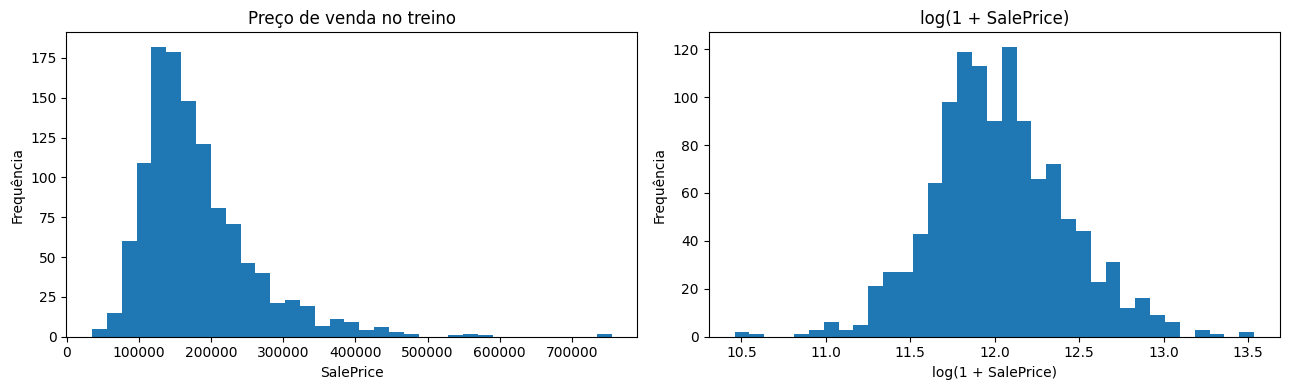

In [8]:
train_df = X_train.copy()
train_df["SalePrice"] = y_train

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_train, bins=35)
axes[0].set_title("Preço de venda no treino")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Frequência")

axes[1].hist(np.log1p(y_train), bins=35)
axes[1].set_title("log(1 + SalePrice)")
axes[1].set_xlabel("log(1 + SalePrice)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

### Interpretação esperada

A transformação logarítmica costuma reduzir a assimetria e comprimir valores muito altos. Isso pode estabilizar a regressão e tornar o erro mais próximo de uma noção relativa.

A transformação não remove a necessidade de analisar erros em dólares. Por isso, as previsões serão invertidas antes das métricas finais.

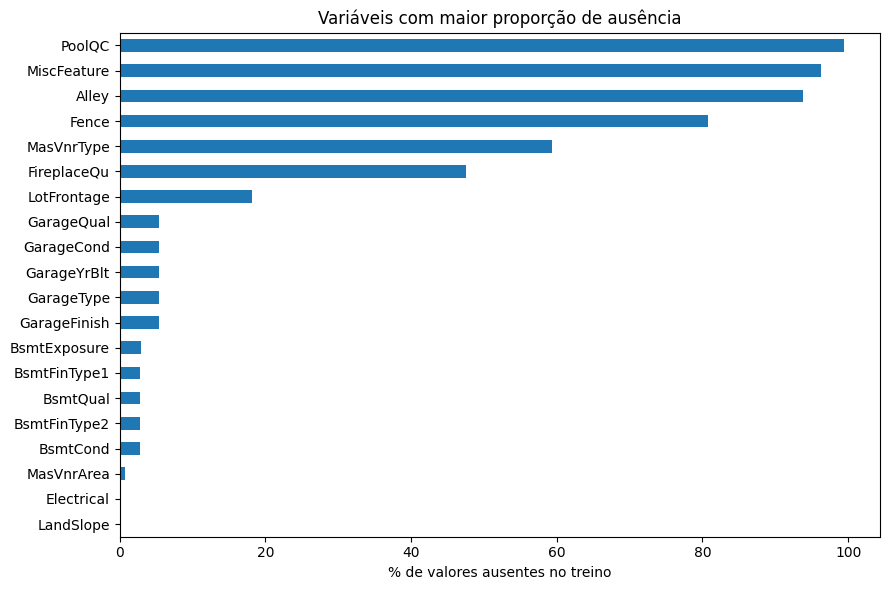

,percentual_ausente
PoolQC,99.400685
MiscFeature,96.318493
Alley,93.750000
Fence,80.736301
MasVnrType,59.332192
FireplaceQu,47.517123
LotFrontage,18.150685
GarageQual,5.393836
GarageFinish,5.393836
GarageType,5.393836


In [9]:
missing = (
    X_train.isna()
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .mul(100)
)

plt.figure(figsize=(9, 6))
missing.sort_values().plot(kind="barh")
plt.xlabel("% de valores ausentes no treino")
plt.title("Variáveis com maior proporção de ausência")
plt.tight_layout()
plt.show()

missing.to_frame("percentual_ausente")

### Cuidado semântico com ausências

Em dados imobiliários, ausência pode significar duas coisas diferentes:

1. valor desconhecido;
2. estrutura inexistente, como piscina, porão ou garagem.

O pipeline didático usa imputação genérica. Um projeto de produção deveria consultar o dicionário dos dados e criar categorias como `"SemPiscina"` quando a ausência tiver significado estrutural.

In [10]:
numeric_cols_eda = X_train.select_dtypes(include="number").columns
corr_to_target = (
    train_df[list(numeric_cols_eda) + ["SalePrice"]]
    .corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=np.abs, ascending=False)
    .head(15)
)

corr_to_target.to_frame("correlacao_com_preco")

,correlacao_com_preco
OverallQual,0.790316
GrLivArea,0.705177
GarageCars,0.637729
GarageArea,0.608436
TotalBsmtSF,0.599422
1stFlrSF,0.598041
FullBath,0.553092
TotRmsAbvGrd,0.517919
YearRemodAdd,0.513843
YearBuilt,0.512284


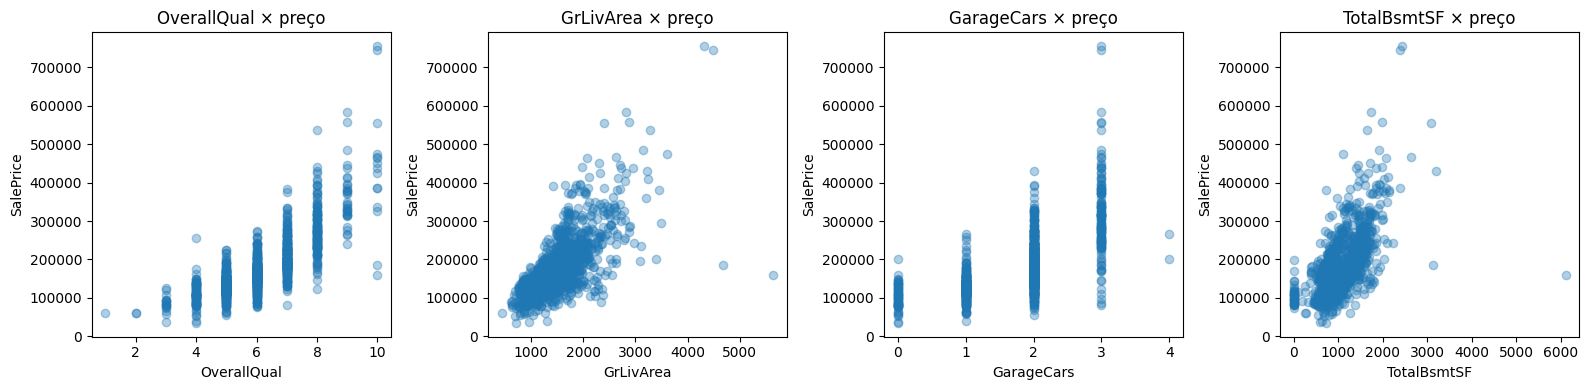

In [11]:
top_numeric = [c for c in ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF"] if c in X_train.columns]

fig, axes = plt.subplots(1, len(top_numeric), figsize=(4 * len(top_numeric), 4))
if len(top_numeric) == 1:
    axes = [axes]

for ax, col in zip(axes, top_numeric):
    ax.scatter(X_train[col], y_train, alpha=0.35)
    ax.set_xlabel(col)
    ax.set_ylabel("SalePrice")
    ax.set_title(f"{col} × preço")

plt.tight_layout()
plt.show()

### Perguntas para interpretar a EDA

<details>
<summary><strong>1. Correlação alta implica que a variável deve entrar no modelo?</strong></summary>

Não. Correlação é marginal e linear. Uma variável pode perder utilidade quando outras entram, pode representar vazamento, pode ser instável ou pode ter relação não linear.

</details>

<details>
<summary><strong>2. Por que não remover imediatamente os pontos mais caros ou maiores?</strong></summary>

Um ponto extremo pode ser erro, caso raro legítimo ou região de interesse. Removê-lo sem critério muda a população-alvo. Primeiro investigamos sua origem e medimos seu efeito na validação.

</details>

<details>
<summary><strong>3. Uma variável com 80% de ausência é necessariamente inútil?</strong></summary>

Não. A presença de uma característica rara, como piscina, pode conter informação. A utilidade deve ser avaliada junto à semântica e à generalização.

</details>

# 6. Métricas e baseline

Um modelo complexo só merece ser usado se superar uma referência simples.

Usaremos a mediana do treino como baseline. A mediana é menos sensível a preços extremos que a média.

In [12]:
def regression_metrics(y_true, y_pred):
    y_pred = np.asarray(y_pred).reshape(-1)
    y_true = np.asarray(y_true).reshape(-1)
    y_pred_nonnegative = np.clip(y_pred, 0, None)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "RMSLE": np.sqrt(mean_squared_log_error(y_true, y_pred_nonnegative)),
        "R2": r2_score(y_true, y_pred),
    }

baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train)

baseline_train_pred = baseline.predict(X_train)
baseline_train_metrics = regression_metrics(y_train, baseline_train_pred)

pd.Series(baseline_train_metrics, name="baseline_treino")

MAE      55462.420377
RMSE     81264.530618
RMSLE        0.397413
R2          -0.051454
Name: baseline_treino, dtype: float64

O desempenho acima é calculado no treino apenas para referência inicial. A comparação séria será feita por validação cruzada e, no fim, pelo teste externo.

# 7. Pipeline de pré-processamento

O pipeline evita vazamento ao aprender imputação, escala e categorias apenas nas observações de treinamento de cada dobra.

## Variáveis numéricas

1. imputação pela mediana;
2. indicadores de ausência;
3. padronização.

## Variáveis categóricas

1. imputação pela categoria mais frequente;
2. one-hot encoding;
3. agrupamento implícito de categorias raras por `min_frequency`.

A padronização é necessária para ridge, lasso, elastic net, PCR e PLS. Sem ela, a penalização depende da unidade de medida.

In [13]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=5,
    )),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

def make_regressor(model):
    full_pipeline = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", model),
    ])
    return TransformedTargetRegressor(
        regressor=full_pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
    )

linear_model = make_regressor(LinearRegression())
ridge_model = make_regressor(Ridge(alpha=10.0, solver="lsqr"))
lasso_model = make_regressor(Lasso(alpha=0.001, max_iter=50_000))
elastic_model = make_regressor(
    ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=50_000)
)

print("Numéricas:", len(numeric_features))
print("Categóricas:", len(categorical_features))

Numéricas: 36
Categóricas: 43


### Pergunta de aprendizagem

<details>
<summary><strong>Por que a imputação deve ficar dentro do pipeline e não ser feita uma vez antes da validação cruzada?</strong></summary>

Se a mediana ou a categoria mais frequente forem calculadas usando todas as linhas, cada dobra de validação influencia o tratamento do treino. Esse vazamento costuma ser discreto, mas produz uma avaliação otimista.

</details>

# 8. Capítulo 5: o problema de uma única divisão

O método do conjunto de validação é simples, mas seu resultado depende de quais observações caem em treino e validação.

Vamos repetir o holdout várias vezes usando um modelo ridge fixo. O objetivo não é escolher $\alpha$, mas observar a variabilidade do RMSE.

In [14]:
holdout = ShuffleSplit(
    n_splits=30 if not FAST_MODE else 12,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

holdout_scores = -cross_val_score(
    ridge_model,
    X_train,
    y_train,
    cv=holdout,
    scoring="neg_root_mean_squared_error",
    n_jobs=N_JOBS,
)

pd.Series(holdout_scores).describe()

count        30.000000
mean      43543.658604
std       36087.842187
min       20946.722014
25%       25264.906763
50%       26480.615212
75%       38317.060908
max      168059.372133
dtype: float64

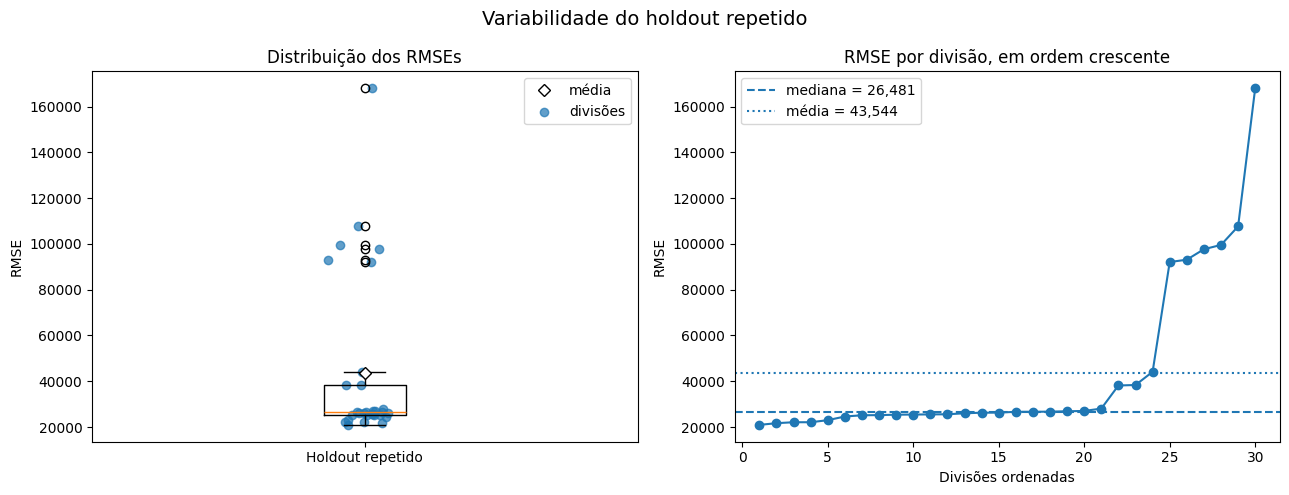

In [15]:
scores = np.asarray(holdout_scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Boxplot vertical com todos os resultados
rng = np.random.default_rng(42)
jitter = rng.normal(loc=1, scale=0.035, size=len(scores))

axes[0].boxplot(
    scores,
    vert=True,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "label": "média"
    }
)

axes[0].scatter(
    jitter,
    scores,
    alpha=0.7,
    label="divisões"
)

axes[0].set_xticks([1])
axes[0].set_xticklabels(["Holdout repetido"])
axes[0].set_ylabel("RMSE")
axes[0].set_title("Distribuição dos RMSEs")
axes[0].legend()


# 2. RMSEs ordenados
scores_ordenados = np.sort(scores)
divisoes = np.arange(1, len(scores_ordenados) + 1)

axes[1].plot(
    divisoes,
    scores_ordenados,
    marker="o"
)

axes[1].axhline(
    np.median(scores),
    linestyle="--",
    label=f"mediana = {np.median(scores):,.0f}"
)

axes[1].axhline(
    np.mean(scores),
    linestyle=":",
    label=f"média = {np.mean(scores):,.0f}"
)

axes[1].set_xlabel("Divisões ordenadas")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE por divisão, em ordem crescente")
axes[1].legend()

fig.suptitle("Variabilidade do holdout repetido", fontsize=14)
plt.tight_layout()
plt.show()

# 9. $k$-fold, LOOCV e validação repetida

## 9.1 $k$-fold

Em $k$-fold, cada observação participa uma vez da validação e $k-1$ vezes do treinamento.

$$
CV_{(k)} = \frac{1}{k}\sum_{j=1}^{k}MSE_j
$$

Valores como 5 ou 10 equilibram custo, viés e variância.

In [18]:
cv_5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_10 = KFold(n_splits=150, shuffle=True, random_state=RANDOM_STATE)

scores_5 = -cross_val_score(
    ridge_model, X_train, y_train,
    cv=cv_5,
    scoring="neg_root_mean_squared_error",
    n_jobs=N_JOBS,
)

scores_10 = -cross_val_score(
    ridge_model, X_train, y_train,
    cv=cv_10,
    scoring="neg_root_mean_squared_error",
    n_jobs=N_JOBS,
)

pd.DataFrame({
    "5-fold": pd.Series(scores_5),
    "10-fold": pd.Series(scores_10),
}).describe()

,5-fold,10-fold
count,5.000000,150.000000
mean,41709.048767,26024.731071
std,28892.060622,44605.304849
min,20814.172923,6950.433067
25%,27033.164194,14568.537986
50%,29795.120681,18663.125663
75%,38827.271063,25439.168619
max,92075.514973,525876.664511


## 9.2 LOOCV em um recorte didático

LOOCV ajusta $n$ modelos. Para manter o custo razoável, usaremos um recorte de 250 observações e apenas três variáveis numéricas.

O objetivo é comparar o mecanismo, não produzir a estimativa final do projeto.

In [19]:
loocv_features = [
    c for c in ["OverallQual", "GrLivArea", "YearBuilt"]
    if c in X_train.columns
]

n_demo = min(10000, len(X_train))
X_loocv = X_train[loocv_features].iloc[:n_demo]
y_loocv = y_train.iloc[:n_demo]

loocv_pipeline = TransformedTargetRegressor(
    regressor=Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0)),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

loocv_rmse = -cross_val_score(
    loocv_pipeline,
    X_loocv,
    y_loocv,
    cv=LeaveOneOut(),
    scoring="neg_root_mean_squared_error",
    n_jobs=N_JOBS,
).mean()

tenfold_demo_rmse = -cross_val_score(
    loocv_pipeline,
    X_loocv,
    y_loocv,
    cv=KFold(10, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_root_mean_squared_error",
    n_jobs=N_JOBS,
).mean()

pd.Series({
    "LOOCV_RMSE": loocv_rmse,
    "10fold_RMSE": tenfold_demo_rmse,
})

LOOCV_RMSE     24399.287440
10fold_RMSE    42810.250526
dtype: float64

### Questão profunda

<details>
<summary><strong>Por que LOOCV pode ter variância maior que 5-fold ou 10-fold?</strong></summary>

Os conjuntos de treino do LOOCV diferem por uma única observação e são fortemente correlacionados. A média de erros altamente correlacionados pode manter variância elevada. Em $k$-fold com $k<n$, os conjuntos diferem mais entre si.

</details>

Cada LOOCV analisa apenas um erro, que por sua vez, pode ser atipico e influenciar de maneira abrupta a variancia. Quando usado k-fold, a variância é composta por no minimo grupos de 5 e 10, sendo mais estável.


## 9.3 Validação cruzada repetida

A validação repetida muda as dobras e permite observar a distribuição da métrica. Ela é útil quando queremos comparar modelos cujas médias são próximas.

In [20]:
repeated_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=REPEATS,
    random_state=RANDOM_STATE,
)

SCORING = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

def summarize_cv(estimator, X_data, y_data, cv):
    result = cross_validate(
        estimator,
        X_data,
        y_data,
        cv=cv,
        scoring=SCORING,
        n_jobs=N_JOBS,
        return_train_score=True,
    )
    return {
        "MAE_CV": -result["test_mae"].mean(),
        "RMSE_CV": -result["test_rmse"].mean(),
        "RMSE_DP": result["test_rmse"].std(),
        "R2_CV": result["test_r2"].mean(),
        "RMSE_TREINO": -result["train_rmse"].mean(),
        "GAP_RMSE": (-result["test_rmse"].mean()) - (-result["train_rmse"].mean()),
    }

initial_models = {
    "Dummy mediana": baseline,
    "OLS completo": linear_model,
    "Ridge fixo": ridge_model,
}

initial_cv_table = pd.DataFrame({
    name: summarize_cv(model, X_train, y_train, repeated_cv)
    for name, model in initial_models.items()
}).T.sort_values("RMSE_CV")

initial_cv_table

,MAE_CV,RMSE_CV,RMSE_DP,R2_CV,RMSE_TREINO,GAP_RMSE
Ridge fixo,17482.362846,41678.385039,27228.352018,0.595857,23289.198295,18389.186744
OLS completo,18937.141411,42725.560100,26134.559801,0.603183,20702.646831,22022.913269
Dummy mediana,55594.140411,81124.866244,6577.972175,-0.057288,81265.036385,-140.170141


### Como interpretar o gap

$$
Gap = RMSE_{validação} - RMSE_{treino}
$$

Um gap grande sugere sobreajuste ou instabilidade. Um gap pequeno com erro alto pode indicar subajuste.

O objetivo não é minimizar o gap isoladamente. Um modelo ruim pode ter treino e validação igualmente ruins.

,MAE_CV,RMSE_CV,R2_CV,RMSE_TREINO,GAP_RMSE
5-fold,24415.696755,46770.845957,0.651712,43898.316498,2872.529459
10-fold,24417.515503,47027.298291,0.647882,44138.752933,2888.545358
LOOCV,24399.287440,46819.392849,0.650989,44354.603527,2464.789323


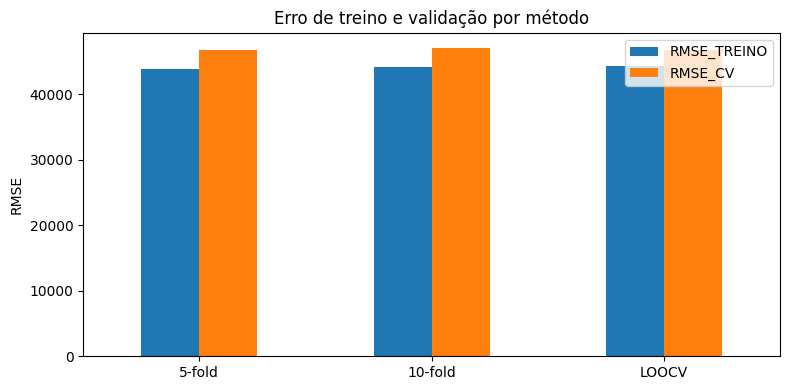

In [28]:
from sklearn.base import clone
from sklearn.model_selection import KFold, LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def avaliar_cv(modelo, X, y, cv):
    y = np.asarray(y)
    pred_oof = np.empty(len(y))
    y_treino, pred_treino = [], []

    for treino, validacao in cv.split(X):
        modelo_fold = clone(modelo)
        modelo_fold.fit(X.iloc[treino], y[treino])

        pred_oof[validacao] = modelo_fold.predict(X.iloc[validacao])
        y_treino.append(y[treino])
        pred_treino.append(modelo_fold.predict(X.iloc[treino]))

    y_treino = np.concatenate(y_treino)
    pred_treino = np.concatenate(pred_treino)

    rmse_cv = mean_squared_error(y, pred_oof) ** 0.5
    rmse_treino = mean_squared_error(y_treino, pred_treino) ** 0.5

    return {
        "MAE_CV": mean_absolute_error(y, pred_oof),
        "RMSE_CV": rmse_cv,
        "R2_CV": r2_score(y, pred_oof),
        "RMSE_TREINO": rmse_treino,
        "GAP_RMSE": rmse_cv - rmse_treino,
    }

metodos_cv = {
    "5-fold": KFold(5, shuffle=True, random_state=RANDOM_STATE),
    "10-fold": KFold(10, shuffle=True, random_state=RANDOM_STATE),
    "LOOCV": LeaveOneOut(),
}

comparacao_cv = pd.DataFrame({
    nome: avaliar_cv(loocv_pipeline, X_loocv, y_loocv, cv)
    for nome, cv in metodos_cv.items()
}).T

display(comparacao_cv)

comparacao_cv[["RMSE_TREINO", "RMSE_CV"]].plot(
    kind="bar",
    figsize=(8, 4),
    rot=0,
    ylabel="RMSE",
    title="Erro de treino e validação por método",
)

plt.tight_layout()
plt.show()

# 10. Capítulo 6: seleção forward em variáveis interpretáveis

A seleção forward começa no modelo nulo e adiciona, em cada etapa, a variável que mais reduz o erro de validação.

Para manter o procedimento transparente e computacionalmente razoável, usaremos um conjunto pré-definido de variáveis numéricas com interpretação imobiliária clara.

A seleção ocorre apenas no treino.

In [39]:
from sklearn.compose import make_column_selector

def mixed_linear_pipeline():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(
            strategy="median",
            add_indicator=True,
        )),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(
            strategy="most_frequent",
        )),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=5,
        )),
    ])

    preprocessor = ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            make_column_selector(dtype_include=np.number),
        ),
        (
            "categorical",
            categorical_pipeline,
            make_column_selector(dtype_exclude=np.number),
        ),
    ])

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", LinearRegression()),
    ])

In [40]:
def forward_selection_path(
    X_data,
    y_data,
    candidate_features,
    cv
):
    selected = []
    remaining = list(candidate_features)
    history = []

    y_log = np.log1p(np.asarray(y_data))

    while remaining:
        step_results = []

        for feature in remaining:
            trial = selected + [feature]

            fold_rmse = -cross_val_score(
                mixed_linear_pipeline(),
                X_data[trial],
                y_log,
                cv=cv,
                scoring="neg_root_mean_squared_error",
                n_jobs=N_JOBS,
            )

            step_results.append({
                "feature_added": feature,
                "mean_rmse_log": fold_rmse.mean(),
                "se_rmse_log": (
                    fold_rmse.std(ddof=1)
                    / np.sqrt(len(fold_rmse))
                ),
            })

        best = min(
            step_results,
            key=lambda row: row["mean_rmse_log"],
        )

        selected.append(best["feature_added"])
        remaining.remove(best["feature_added"])

        history.append({
            "n_features": len(selected),
            "selected_features": tuple(selected),
            **best,
        })

        print(
            f"{len(selected):02d}/{len(candidate_features)} | "
            f"{best['feature_added']} | "
            f"RMSE log: {best['mean_rmse_log']:.5f}"
        )

    return pd.DataFrame(history)

In [41]:
ALL_FEATURES = X_train.columns.tolist()

forward_path_all = forward_selection_path(
    X_train,
    y_train,
    ALL_FEATURES,
    forward_cv,
)

forward_path_all[
    [
        "n_features",
        "feature_added",
        "mean_rmse_log",
        "se_rmse_log",
    ]
]

01/79 | OverallQual | RMSE log: 0.23064
02/79 | Neighborhood | RMSE log: 0.19672
03/79 | GrLivArea | RMSE log: 0.17282
04/79 | BsmtFinType1 | RMSE log: 0.16449
05/79 | GarageCars | RMSE log: 0.15835
06/79 | OverallCond | RMSE log: 0.15287
07/79 | YearBuilt | RMSE log: 0.14943
08/79 | BldgType | RMSE log: 0.14624
09/79 | BsmtExposure | RMSE log: 0.14418
10/79 | ScreenPorch | RMSE log: 0.14252
11/79 | BsmtFullBath | RMSE log: 0.14123
12/79 | BsmtUnfSF | RMSE log: 0.14011
13/79 | WoodDeckSF | RMSE log: 0.13893
14/79 | Heating | RMSE log: 0.13810
15/79 | Fireplaces | RMSE log: 0.13720
16/79 | Foundation | RMSE log: 0.13638
17/79 | MSZoning | RMSE log: 0.13567
18/79 | GarageFinish | RMSE log: 0.13507
19/79 | MSSubClass | RMSE log: 0.13466
20/79 | YearRemodAdd | RMSE log: 0.13434
21/79 | Functional | RMSE log: 0.13395
22/79 | GarageQual | RMSE log: 0.13375
23/79 | TotRmsAbvGrd | RMSE log: 0.13365
24/79 | BsmtFinSF2 | RMSE log: 0.13354
25/79 | 3SsnPorch | RMSE log: 0.13344
26/79 | KitchenAbvG

,n_features,feature_added,mean_rmse_log,se_rmse_log
0,1,OverallQual,0.230644,0.005947
1,2,Neighborhood,0.196721,0.003332
2,3,GrLivArea,0.172817,0.007764
3,4,BsmtFinType1,0.164493,0.008388
4,5,GarageCars,0.158348,0.008503
...,...,...,...,...
74,75,TotalBsmtSF,0.151461,0.010645
75,76,BsmtFinSF1,0.151461,0.010645
76,77,RoofStyle,0.153895,0.011469
77,78,SaleCondition,0.157034,0.011488


In [43]:
best_idx = forward_path_all["mean_rmse_log"].idxmin()
best_rmse = forward_path_all.loc[best_idx, "mean_rmse_log"]
best_se = forward_path_all.loc[best_idx, "se_rmse_log"]
threshold_1se = best_rmse + best_se

eligible = forward_path_all[
    forward_path_all["mean_rmse_log"] <= threshold_1se
]

one_se_row = eligible.sort_values("n_features").iloc[0]
selected_forward_features = list(one_se_row["selected_features"])

print("Menor RMSE log:", best_rmse)
print("Limite de 1 erro-padrão:", threshold_1se)
print("Número de variáveis pela regra 1-SE:", len(selected_forward_features))
print("Variáveis selecionadas:", selected_forward_features)

Menor RMSE log: 0.13258548528183586
Limite de 1 erro-padrão: 0.1407237235823486
Número de variáveis pela regra 1-SE: 12
Variáveis selecionadas: ['OverallQual', 'Neighborhood', 'GrLivArea', 'BsmtFinType1', 'GarageCars', 'OverallCond', 'YearBuilt', 'BldgType', 'BsmtExposure', 'ScreenPorch', 'BsmtFullBath', 'BsmtUnfSF']


O melhor RMSE médio encontrado foi 0,1326. Considerando a incerteza estimada pela validação cruzada, modelos com RMSE até 0,1407 são tratados como competitivos. O menor modelo dentro dessa faixa possui 12 variáveis, então ele foi escolhido pela regra 1-SE. (1 STANDARD ERROR)

Método usado para utilizar para considerar também o modelo menos complexo possível

In [21]:
CURATED_FEATURES = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "YearBuilt",
    "YearRemodAdd",
    "TotRmsAbvGrd",
    "Fireplaces",
    "LotArea",
    "MasVnrArea",
    "BsmtFinSF1",
]

# CURATED_FEATURES = X_train.columns
CURATED_FEATURES = [c for c in CURATED_FEATURES if c in X_train.columns]
CURATED_FEATURES

['OverallQual',
 'GrLivArea',
 'GarageCars',
 'GarageArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'FullBath',
 'YearBuilt',
 'YearRemodAdd',
 'TotRmsAbvGrd',
 'Fireplaces',
 'LotArea',
 'MasVnrArea',
 'BsmtFinSF1']

In [22]:
def numeric_linear_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])

def forward_selection_path(X_data, y_data, candidate_features, cv):
    selected = []
    remaining = list(candidate_features)
    history = []

    y_log = np.log1p(np.asarray(y_data))

    while remaining:
        step_results = []

        for feature in remaining:
            trial = selected + [feature]
            fold_rmse = -cross_val_score(
                numeric_linear_pipeline(),
                X_data[trial],
                y_log,
                cv=cv,
                scoring="neg_root_mean_squared_error",
                n_jobs=N_JOBS,
            )
            step_results.append({
                "feature_added": feature,
                "mean_rmse_log": fold_rmse.mean(),
                "se_rmse_log": fold_rmse.std(ddof=1) / np.sqrt(len(fold_rmse)),
            })

        best = min(step_results, key=lambda row: row["mean_rmse_log"])
        selected.append(best["feature_added"])
        remaining.remove(best["feature_added"])

        history.append({
            "n_features": len(selected),
            "selected_features": tuple(selected),
            **best,
        })

    return pd.DataFrame(history)

forward_cv = KFold(
    n_splits=INNER_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

forward_path = forward_selection_path(
    X_train,
    y_train,
    CURATED_FEATURES,
    forward_cv,
)

forward_path[["n_features", "feature_added", "mean_rmse_log", "se_rmse_log"]]

,n_features,feature_added,mean_rmse_log,se_rmse_log
0,1,OverallQual,0.230644,0.005947
1,2,GrLivArea,0.207213,0.010286
2,3,YearBuilt,0.190388,0.011237
3,4,GarageCars,0.183056,0.011202
4,5,Fireplaces,0.178249,0.010954
5,6,YearRemodAdd,0.174665,0.010250
6,7,BsmtFinSF1,0.171402,0.014565
7,8,LotArea,0.169420,0.015447
8,9,1stFlrSF,0.169329,0.016084
9,10,TotRmsAbvGrd,0.169620,0.015557


In [23]:
best_idx = forward_path["mean_rmse_log"].idxmin()
best_rmse = forward_path.loc[best_idx, "mean_rmse_log"]
best_se = forward_path.loc[best_idx, "se_rmse_log"]
threshold_1se = best_rmse + best_se

eligible = forward_path[
    forward_path["mean_rmse_log"] <= threshold_1se
]

one_se_row = eligible.sort_values("n_features").iloc[0]
selected_forward_features = list(one_se_row["selected_features"])

print("Menor RMSE log:", best_rmse)
print("Limite de 1 erro-padrão:", threshold_1se)
print("Número de variáveis pela regra 1-SE:", len(selected_forward_features))
print("Variáveis selecionadas:", selected_forward_features)

Menor RMSE log: 0.169329443787289
Limite de 1 erro-padrão: 0.1854139305927069
Número de variáveis pela regra 1-SE: 4
Variáveis selecionadas: ['OverallQual', 'GrLivArea', 'YearBuilt', 'GarageCars']


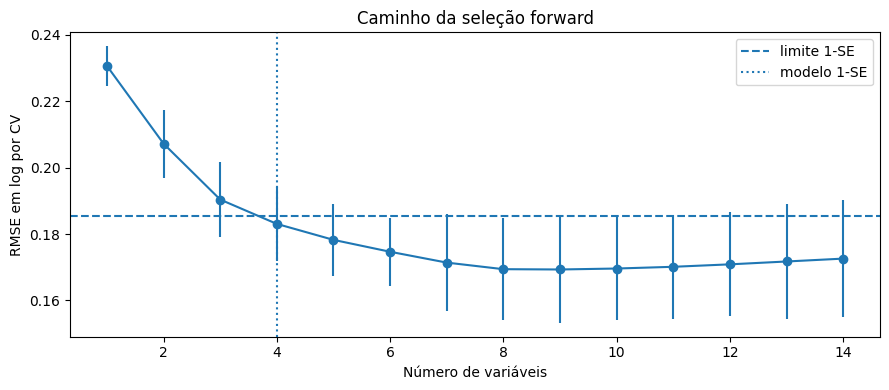

In [24]:
plt.figure(figsize=(9, 4))
plt.errorbar(
    forward_path["n_features"],
    forward_path["mean_rmse_log"],
    yerr=forward_path["se_rmse_log"],
    marker="o",
)
plt.axhline(threshold_1se, linestyle="--", label="limite 1-SE")
plt.axvline(len(selected_forward_features), linestyle=":", label="modelo 1-SE")
plt.xlabel("Número de variáveis")
plt.ylabel("RMSE em log por CV")
plt.title("Caminho da seleção forward")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretação

O modelo com menor erro médio não precisa ser a escolha final. A regra de um erro-padrão seleciona o menor modelo cujo erro ainda é compatível com o mínimo, considerando a incerteza da validação cruzada.

Essa regra troca uma pequena diferença estimada de desempenho por:

- menor custo de coleta;
- interpretação mais simples;
- menor sensibilidade a variações da amostra.

### Questão profunda

<details>
<summary><strong>A seleção forward encontrou as “verdadeiras causas” do preço?</strong></summary>

Não. Ela encontrou um subconjunto útil para previsão sob uma amostra, um algoritmo e uma métrica. Preditores correlacionados podem substituir uns aos outros. Seleção de variáveis não equivale a identificação causal.

</details>

## 10.1 Melhor subconjunto, extensão opcional

A busca exaustiva cresce como $2^p$. Para observar o custo, a célula abaixo pode testar todas as combinações de um grupo pequeno de variáveis.

Ela fica desativada por padrão.

In [26]:
RUN_BEST_SUBSET = True

if RUN_BEST_SUBSET:
    from itertools import combinations

    subset_features = CURATED_FEATURES[:7 if FAST_MODE else 9]
    subset_rows = []
    y_log = np.log1p(np.asarray(y_train))

    for size in range(1, len(subset_features) + 1):
        for subset in combinations(subset_features, size):
            scores = -cross_val_score(
                numeric_linear_pipeline(),
                X_train[list(subset)],
                y_log,
                cv=forward_cv,
                scoring="neg_root_mean_squared_error",
                n_jobs=N_JOBS,
            )
            subset_rows.append({
                "size": size,
                "features": subset,
                "rmse_log": scores.mean(),
            })

    best_subset_table = (
        pd.DataFrame(subset_rows)
        .sort_values(["size", "rmse_log"])
        .groupby("size", as_index=False)
        .first()
    )
    display(best_subset_table)
else:
    print("Busca exaustiva desativada. Defina RUN_BEST_SUBSET = True para executar.")

,size,features,rmse_log
0,1,"(OverallQual,)",0.230644
1,2,"(OverallQual, GrLivArea)",0.207213
2,3,"(OverallQual, GrLivArea, YearBuilt)",0.190388
3,4,"(OverallQual, GrLivArea, GarageCars, YearBuilt)",0.183056
4,5,"(OverallQual, GrLivArea, GarageCars, 1stFlrSF,...",0.180121
5,6,"(OverallQual, GrLivArea, GarageCars, 1stFlrSF,...",0.177664
6,7,"(OverallQual, GrLivArea, GarageCars, 1stFlrSF,...",0.178048
7,8,"(OverallQual, GrLivArea, GarageCars, TotalBsmt...",0.178923
8,9,"(OverallQual, GrLivArea, GarageCars, GarageAre...",0.179760


# 11. Ridge, lasso e elastic net

## 11.1 Funções objetivo

Ridge minimiza:

$$
RSS + \lambda\sum_{j=1}^{p}\beta_j^2
$$

Lasso minimiza:

$$
RSS + \lambda\sum_{j=1}^{p}|\beta_j|
$$

Elastic net combina as duas penalizações.

Ridge tende a distribuir peso entre variáveis correlacionadas. Lasso pode zerar coeficientes. Elastic net pode produzir esparsidade sem escolher arbitrariamente apenas uma variável de um grupo fortemente correlacionado.

In [27]:
inner_cv = KFold(
    n_splits=INNER_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

ridge_search = GridSearchCV(
    make_regressor(Ridge(solver="lsqr")),
    param_grid={"regressor__model__alpha": ALPHAS},
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=N_JOBS,
)

lasso_search = GridSearchCV(
    make_regressor(Lasso(max_iter=50_000)),
    param_grid={"regressor__model__alpha": ALPHAS},
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=N_JOBS,
)

elastic_search = GridSearchCV(
    make_regressor(ElasticNet(max_iter=50_000)),
    param_grid={
        "regressor__model__alpha": ALPHAS,
        "regressor__model__l1_ratio": [0.1, 0.5, 0.9, 1.0],
    },
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=N_JOBS,
)

Antes de executar, faça uma previsão:

<details>
<summary><strong>Qual método deve selecionar menos variáveis?</strong></summary>

Lasso tende a produzir mais coeficientes exatamente iguais a zero. Ridge mantém todos os coeficientes. Elastic net pode produzir esparsidade, dependendo de `l1_ratio`.

</details>

In [29]:
t0 = time.time()

ridge_search.fit(X_train, y_train)
lasso_search.fit(X_train, y_train)
elastic_search.fit(X_train, y_train)

print("Tempo total de tuning:", round(time.time() - t0, 1), "s")
print("Ridge:", ridge_search.best_params_)
print("Lasso:", lasso_search.best_params_)
print("Elastic net:", elastic_search.best_params_)

Tempo total de tuning: 20.8 s
Ridge: {'regressor__model__alpha': np.float64(0.19684194472866112)}
Lasso: {'regressor__model__alpha': np.float64(0.0005080218046913023)}
Elastic net: {'regressor__model__alpha': np.float64(0.0005080218046913023), 'regressor__model__l1_ratio': 0.9}


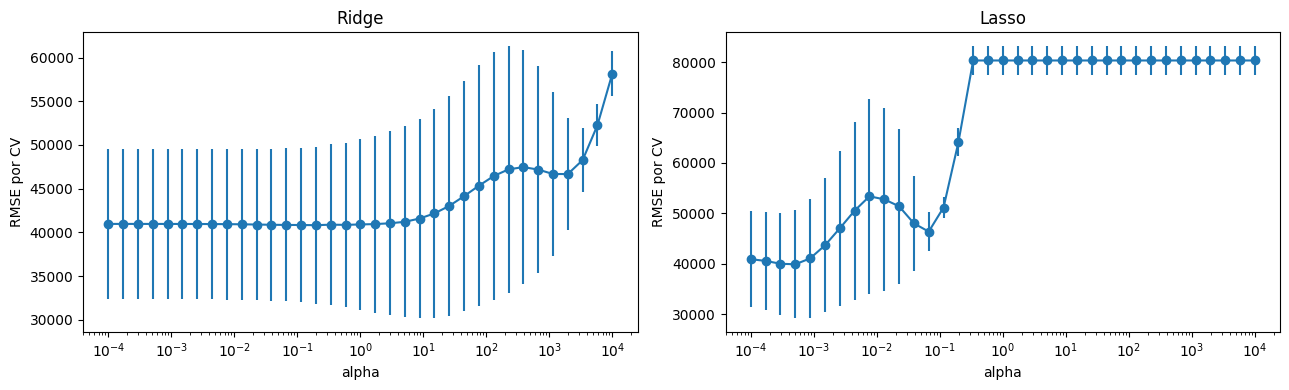

In [30]:
def tuning_curve(search, param_name):
    result = pd.DataFrame(search.cv_results_).copy()
    result["rmse"] = -result["mean_test_score"]
    result["se"] = result["std_test_score"] / np.sqrt(INNER_FOLDS)
    return result.sort_values(param_name)

ridge_curve = tuning_curve(ridge_search, "param_regressor__model__alpha")
lasso_curve = tuning_curve(lasso_search, "param_regressor__model__alpha")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, curve, title in [
    (axes[0], ridge_curve, "Ridge"),
    (axes[1], lasso_curve, "Lasso"),
]:
    x = curve["param_regressor__model__alpha"].astype(float)
    ax.errorbar(x, curve["rmse"], yerr=curve["se"], marker="o")
    ax.set_xscale("log")
    ax.set_xlabel("alpha")
    ax.set_ylabel("RMSE por CV")
    ax.set_title(title)

plt.tight_layout()
plt.show()

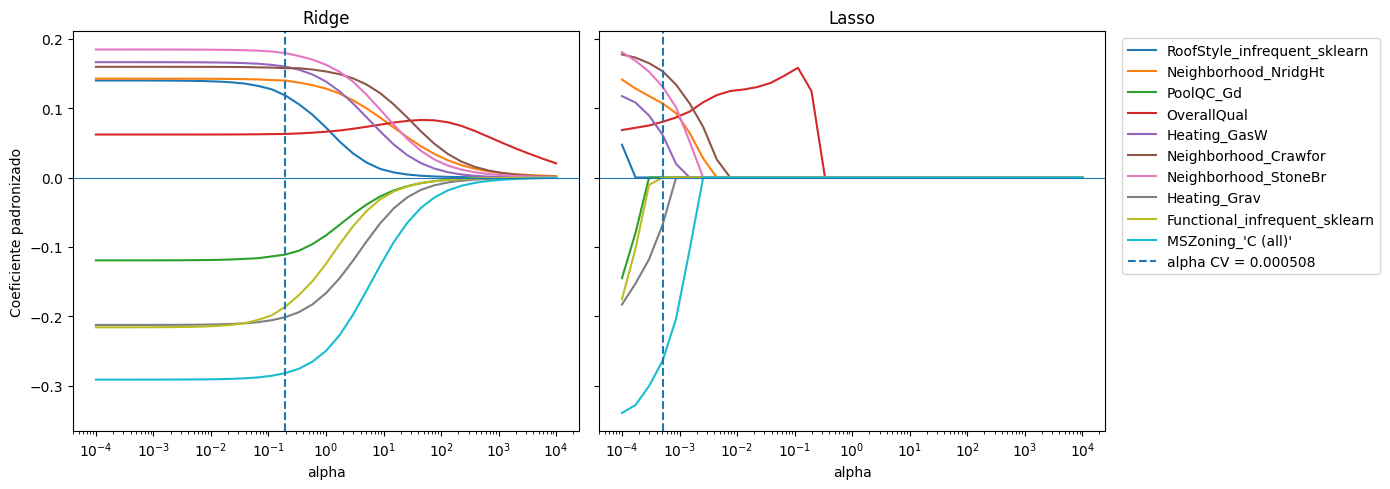

In [34]:
# Caminho dos coeficientes: encolhimento dos parâmetros conforme alpha aumenta
prep_path = clone(preprocessor)
X_path = prep_path.fit_transform(X_train)

if hasattr(X_path, "toarray"):
    X_path = X_path.toarray()

y_path = np.log1p(np.asarray(y_train))
feature_names = prep_path.get_feature_names_out()

ridge_coefs = np.array([
    Ridge(alpha=alpha, solver="lsqr").fit(X_path, y_path).coef_
    for alpha in ALPHAS
])

lasso_coefs = np.array([
    Lasso(alpha=alpha, max_iter=100_000).fit(X_path, y_path).coef_
    for alpha in ALPHAS
])

# Exibe os 10 termos com maiores coeficientes ao longo dos caminhos
magnitude = np.maximum(
    np.abs(ridge_coefs).max(axis=0),
    np.abs(lasso_coefs).max(axis=0),
)
top_idx = np.argsort(magnitude)[-10:]

ridge_alpha = ridge_search.best_params_["regressor__model__alpha"]
lasso_alpha = lasso_search.best_params_["regressor__model__alpha"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx in top_idx:
    label = feature_names[idx].replace("num__", "").replace("cat__", "")

    axes[0].plot(ALPHAS, ridge_coefs[:, idx], label=label)
    axes[1].plot(ALPHAS, lasso_coefs[:, idx], label=label)

for ax, title, best_alpha in [
    (axes[0], "Ridge", ridge_alpha),
    (axes[1], "Lasso", lasso_alpha),
]:
    ax.axvline(best_alpha, linestyle="--", label=f"alpha CV = {best_alpha:.3g}")
    ax.axhline(0, linewidth=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("alpha")
    ax.set_title(title)

axes[0].set_ylabel("Coeficiente padronizado")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Leitura das curvas

Uma curva plana perto do mínimo significa que vários valores de regularização têm desempenho compatível.

Escolher o mínimo exato pode dar uma falsa sensação de precisão. Uma alternativa é escolher um $\alpha$ mais regularizado dentro de um erro-padrão do mínimo.

In [31]:
def alpha_one_se(search, alpha_column="param_regressor__model__alpha"):
    result = pd.DataFrame(search.cv_results_).copy()
    result["rmse"] = -result["mean_test_score"]
    result["se"] = result["std_test_score"] / np.sqrt(INNER_FOLDS)

    best_idx = result["rmse"].idxmin()
    threshold = result.loc[best_idx, "rmse"] + result.loc[best_idx, "se"]

    eligible = result[result["rmse"] <= threshold].copy()
    eligible["alpha_float"] = eligible[alpha_column].astype(float)

    return {
        "alpha_min": float(result.loc[best_idx, alpha_column]),
        "alpha_1se": float(eligible["alpha_float"].max()),
        "rmse_min": result.loc[best_idx, "rmse"],
        "threshold": threshold,
    }

pd.DataFrame({
    "Ridge": alpha_one_se(ridge_search),
    "Lasso": alpha_one_se(lasso_search),
}).T

,alpha_min,alpha_1se,rmse_min,threshold
Ridge,0.196842,3383.855153,40826.211537,49806.631236
Lasso,0.000508,0.066608,39917.285037,50661.737208


## 11.2 Coeficientes e esparsidade

Os modelos foram ajustados na escala logarítmica da resposta e com preditores padronizados. Os coeficientes indicam direção e magnitude no espaço transformado, não uma variação direta em dólares.

A leitura deve priorizar estabilidade e coerência, não apenas o ranking absoluto.

In [32]:
def fitted_coefficients(fitted_ttr):
    fitted_pipeline = fitted_ttr.regressor_
    prep = fitted_pipeline.named_steps["preprocess"]
    model = fitted_pipeline.named_steps["model"]

    feature_names = prep.get_feature_names_out()
    coef = np.asarray(model.coef_).reshape(-1)

    table = pd.DataFrame({
        "feature": feature_names,
        "coef": coef,
        "abs_coef": np.abs(coef),
    }).sort_values("abs_coef", ascending=False)

    return table

ridge_coef = fitted_coefficients(ridge_search.best_estimator_)
lasso_coef = fitted_coefficients(lasso_search.best_estimator_)
elastic_coef = fitted_coefficients(elastic_search.best_estimator_)

coef_summary = pd.DataFrame({
    "modelo": ["Ridge", "Lasso", "Elastic net"],
    "coeficientes": [len(ridge_coef), len(lasso_coef), len(elastic_coef)],
    "nao_zero": [
        (ridge_coef["coef"].abs() > 1e-10).sum(),
        (lasso_coef["coef"].abs() > 1e-10).sum(),
        (elastic_coef["coef"].abs() > 1e-10).sum(),
    ],
})
coef_summary["zerados"] = coef_summary["coeficientes"] - coef_summary["nao_zero"]
coef_summary

,modelo,coeficientes,nao_zero,zerados
0,Ridge,258,257,1
1,Lasso,258,104,154
2,Elastic net,258,115,143


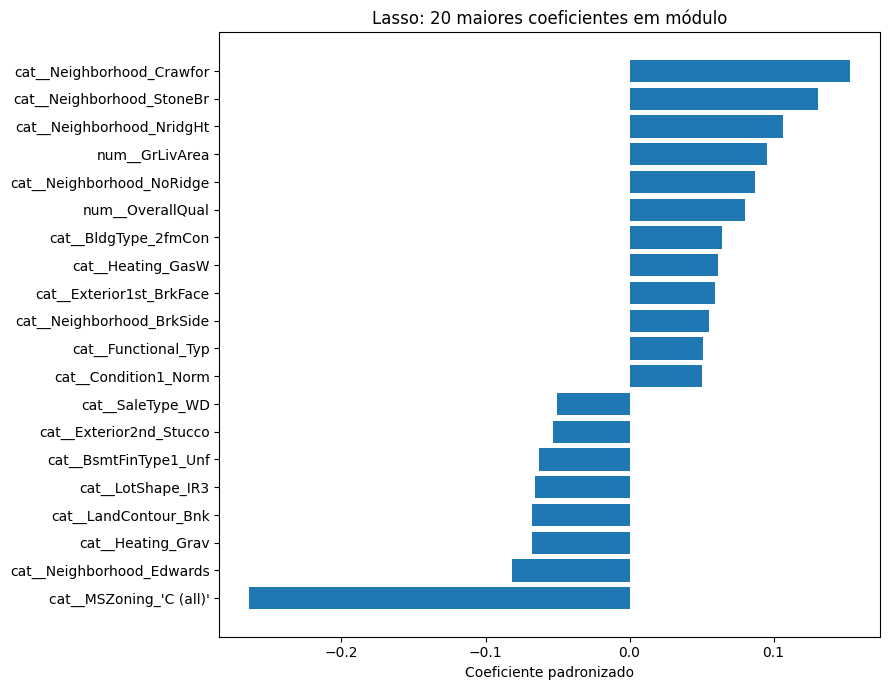

In [33]:
top_lasso = lasso_coef.head(20).sort_values("coef")

plt.figure(figsize=(9, 7))
plt.barh(top_lasso["feature"], top_lasso["coef"])
plt.xlabel("Coeficiente padronizado")
plt.title("Lasso: 20 maiores coeficientes em módulo")
plt.tight_layout()
plt.show()

### Cuidado interpretativo

One-hot encoding cria comparações em relação a categorias de referência. Um coeficiente categórico não deve ser lido isoladamente sem identificar a codificação e a categoria de comparação.

Coeficientes altos também podem variar bastante entre amostras quando preditores são correlacionados.

# 12. Redução de dimensão: PCR e PLS

PCR cria componentes que explicam a variabilidade de $X$, sem usar $Y$ na construção.

PLS cria componentes orientados também pela associação com $Y$.

Para manter os componentes interpretáveis e o custo controlado, aplicaremos ambos às variáveis numéricas selecionadas para o laboratório.

In [35]:
X_num_train = X_train[CURATED_FEATURES].copy()
max_components = min(len(CURATED_FEATURES), 12)

pcr = TransformedTargetRegressor(
    regressor=Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA()),
        ("model", LinearRegression()),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

pls = TransformedTargetRegressor(
    regressor=Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(scale=False)),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

pcr_search = GridSearchCV(
    pcr,
    param_grid={"regressor__pca__n_components": range(1, max_components + 1)},
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=N_JOBS,
)

pls_search = GridSearchCV(
    pls,
    param_grid={"regressor__pls__n_components": range(1, max_components + 1)},
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=N_JOBS,
)

pcr_search.fit(X_num_train, y_train)
pls_search.fit(X_num_train, y_train)

print("PCR:", pcr_search.best_params_)
print("PLS:", pls_search.best_params_)

PCR: {'regressor__pca__n_components': 7}
PLS: {'regressor__pls__n_components': 2}


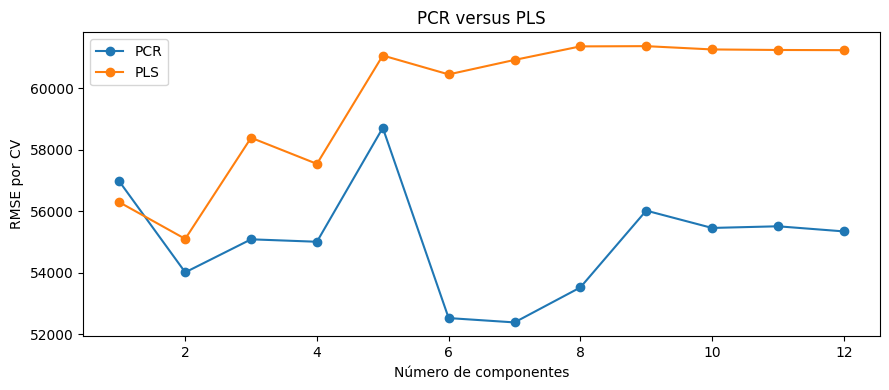

In [36]:
pcr_result = pd.DataFrame(pcr_search.cv_results_)
pls_result = pd.DataFrame(pls_search.cv_results_)

plt.figure(figsize=(9, 4))
plt.plot(
    pcr_result["param_regressor__pca__n_components"].astype(int),
    -pcr_result["mean_test_score"],
    marker="o",
    label="PCR",
)
plt.plot(
    pls_result["param_regressor__pls__n_components"].astype(int),
    -pls_result["mean_test_score"],
    marker="o",
    label="PLS",
)
plt.xlabel("Número de componentes")
plt.ylabel("RMSE por CV")
plt.title("PCR versus PLS")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
best_pca = pcr_search.best_estimator_.regressor_.named_steps["pca"]
explained = pd.Series(
    best_pca.explained_variance_ratio_,
    index=np.arange(1, best_pca.n_components_ + 1),
    name="variancia_explicada",
)

explained.to_frame().assign(
    acumulada=explained.cumsum()
)

,variancia_explicada,acumulada
1,0.417061,0.417061
2,0.119694,0.536755
3,0.105959,0.642714
4,0.061443,0.704156
5,0.060503,0.764660
6,0.051648,0.816307
7,0.046422,0.862729


### Questão profunda

<details>
<summary><strong>Se os primeiros componentes explicam 90% de $X$, eles devem prever bem $Y$?</strong></summary>

Não necessariamente. Uma direção pode explicar muita variação dos imóveis e ter pouca relação com preço. PCR assume que direções importantes para $X$ também são úteis para $Y$. PLS usa $Y$ para construir as direções, mas pode aumentar a variância.

</details>

# 13. Bootstrap: estabilidade dos coeficientes e da seleção

Validação cruzada estima desempenho fora da amostra. Bootstrap responde outra pergunta: quanto uma estimativa muda quando perturbamos a amostra?

Vamos medir a estabilidade dos coeficientes do lasso em um conjunto numérico reduzido.

O $\alpha$ será fixado após uma escolha por validação cruzada. Em cada amostra bootstrap:

1. sorteamos linhas com reposição;
2. ajustamos o lasso;
3. registramos coeficientes;
4. calculamos a frequência com que cada variável fica diferente de zero.

In [38]:
numeric_lasso = TransformedTargetRegressor(
    regressor=Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Lasso(max_iter=50_000)),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

numeric_lasso_search = GridSearchCV(
    numeric_lasso,
    param_grid={"regressor__model__alpha": ALPHAS},
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=N_JOBS,
)
numeric_lasso_search.fit(X_num_train, y_train)

numeric_lasso_alpha = numeric_lasso_search.best_params_["regressor__model__alpha"]
numeric_lasso_alpha

np.float64(0.06660846290809154)

In [39]:
bootstrap_coefs = []

for b in range(BOOTSTRAP_B):
    sample_idx = rng.integers(0, len(X_num_train), len(X_num_train))

    X_b = X_num_train.iloc[sample_idx]
    y_b = y_train.iloc[sample_idx]

    model_b = TransformedTargetRegressor(
        regressor=Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Lasso(
                alpha=numeric_lasso_alpha,
                max_iter=50_000,
            )),
        ]),
        func=np.log1p,
        inverse_func=np.expm1,
    )
    model_b.fit(X_b, y_b)

    coef_b = model_b.regressor_.named_steps["model"].coef_
    bootstrap_coefs.append(coef_b)

bootstrap_coefs = pd.DataFrame(
    bootstrap_coefs,
    columns=CURATED_FEATURES,
)

In [40]:
stability = pd.DataFrame({
    "media_coef": bootstrap_coefs.mean(),
    "desvio_coef": bootstrap_coefs.std(),
    "q025": bootstrap_coefs.quantile(0.025),
    "q975": bootstrap_coefs.quantile(0.975),
    "frequencia_selecao": (bootstrap_coefs.abs() > 1e-10).mean(),
})

stability["sinal_estavel"] = (
    (stability["q025"] > 0) | (stability["q975"] < 0)
)

stability.sort_values(
    ["frequencia_selecao", "media_coef"],
    ascending=[False, False],
)

,media_coef,desvio_coef,q025,q975,frequencia_selecao,sinal_estavel
OverallQual,0.145247,0.013800,0.119305,0.172464,1.000,True
GrLivArea,0.076967,0.014566,0.046176,0.102302,1.000,True
GarageCars,0.044396,0.012987,0.018637,0.068584,0.999,True
YearBuilt,0.021940,0.008768,0.004103,0.038876,0.985,True
YearRemodAdd,0.016074,0.007575,0.000311,0.030614,0.978,True
TotalBsmtSF,0.020887,0.016519,0.000000,0.050587,0.788,False
Fireplaces,0.005918,0.005811,0.000000,0.018768,0.747,False
1stFlrSF,0.003543,0.005602,0.000000,0.018913,0.456,False
BsmtFinSF1,0.002876,0.004915,0.000000,0.015819,0.370,False
GarageArea,0.002166,0.005189,0.000000,0.018516,0.243,False


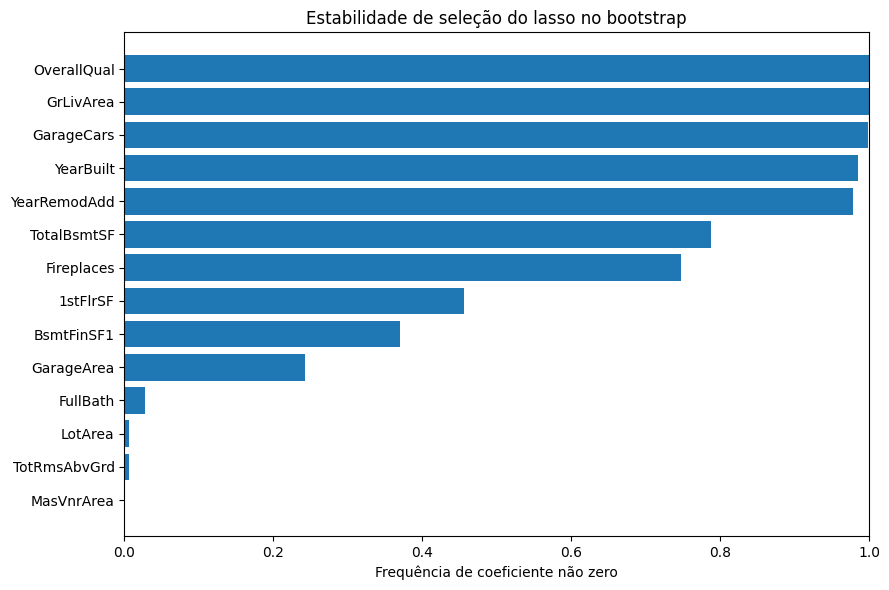

In [41]:
stable_plot = stability.sort_values("frequencia_selecao")

plt.figure(figsize=(9, 6))
plt.barh(stable_plot.index, stable_plot["frequencia_selecao"])
plt.xlabel("Frequência de coeficiente não zero")
plt.title("Estabilidade de seleção do lasso no bootstrap")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

### Interpretação

Uma variável selecionada em 100% das amostras é mais estável que outra selecionada em 52%.

Frequência alta ainda não prova causalidade. Ela indica robustez da seleção sob perturbações semelhantes à amostra observada.

Quando duas variáveis são fortemente correlacionadas, o lasso pode alternar entre elas. Nesse caso, cada frequência individual pode ser moderada, embora o grupo seja importante.

# 14. Comparação honesta com validação cruzada aninhada

Usar a mesma validação cruzada para escolher hiperparâmetros e reportar desempenho pode produzir otimismo.

Na validação aninhada:

- o ciclo interno escolhe hiperparâmetros;
- o ciclo externo estima generalização.

A comparação abaixo inclui OLS, ridge, lasso e elastic net com todos os preditores. PCR e PLS são avaliados no conjunto numérico reduzido e aparecem depois em tabela separada.

In [42]:
outer_cv = KFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE + 1,
)

full_candidates = {
    "OLS completo": linear_model,
    "Ridge ajustado": clone(ridge_search),
    "Lasso ajustado": clone(lasso_search),
    "Elastic net ajustado": clone(elastic_search),
}

nested_rows = []

for name, estimator in full_candidates.items():
    result = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=outer_cv,
        scoring=SCORING,
        n_jobs=N_JOBS,
        return_train_score=False,
    )

    nested_rows.append({
        "modelo": name,
        "MAE": -result["test_mae"].mean(),
        "RMSE": -result["test_rmse"].mean(),
        "RMSE_DP": result["test_rmse"].std(ddof=1),
        "R2": result["test_r2"].mean(),
    })

nested_results = (
    pd.DataFrame(nested_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

nested_results

,modelo,MAE,RMSE,RMSE_DP,R2
0,OLS completo,19231.293326,42920.269715,25723.542912,0.611229
1,Elastic net ajustado,21939.764739,47116.399948,27905.955298,0.545763
2,Ridge ajustado,20768.172314,47130.795902,28679.836786,0.536928
3,Lasso ajustado,23348.589816,49321.011657,25800.704066,0.522998


In [43]:
reduced_candidates = {
    "Forward 1-SE": TransformedTargetRegressor(
        regressor=Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        func=np.log1p,
        inverse_func=np.expm1,
    ),
    "PCR ajustado": clone(pcr_search),
    "PLS ajustado": clone(pls_search),
}

reduced_data = {
    "Forward 1-SE": X_train[selected_forward_features],
    "PCR ajustado": X_num_train,
    "PLS ajustado": X_num_train,
}

reduced_rows = []

for name, estimator in reduced_candidates.items():
    result = cross_validate(
        estimator,
        reduced_data[name],
        y_train,
        cv=outer_cv,
        scoring=SCORING,
        n_jobs=N_JOBS,
    )

    reduced_rows.append({
        "modelo": name,
        "n_variaveis_originais": (
            len(selected_forward_features)
            if name == "Forward 1-SE"
            else len(CURATED_FEATURES)
        ),
        "MAE": -result["test_mae"].mean(),
        "RMSE": -result["test_rmse"].mean(),
        "RMSE_DP": result["test_rmse"].std(ddof=1),
        "R2": result["test_r2"].mean(),
    })

reduced_results = (
    pd.DataFrame(reduced_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

reduced_results

,modelo,n_variaveis_originais,MAE,RMSE,RMSE_DP,R2
0,Forward 1-SE,4,23419.731418,40331.345450,12952.319927,0.721730
1,PLS ajustado,14,22156.559308,53136.988392,41632.997992,0.311027
2,PCR ajustado,14,22694.519015,55464.941208,45798.229571,0.217243


### Como decidir quando as médias são próximas

Não conclua vitória apenas pela menor média. Compare:

- diferença entre médias;
- desvio entre dobras;
- quantidade e custo das variáveis;
- estabilidade;
- interpretabilidade;
- tempo de ajuste;
- risco de mudança de distribuição.

Dois modelos podem ser estatisticamente indistinguíveis para o tamanho da amostra disponível.

# 15. Escolha e ajuste do modelo final

A regra abaixo escolhe o primeiro colocado da validação aninhada entre os modelos completos.

Em um projeto real, essa decisão também poderia impor restrições, por exemplo:

- no máximo 20 variáveis;
- latência inferior a certo limite;
- ausência de atributos sensíveis;
- erro máximo por faixa de preço;
- estabilidade mínima entre períodos.

In [44]:
best_name = nested_results.iloc[0]["modelo"]
best_name

'OLS completo'

In [45]:
final_estimators = {
    "OLS completo": clone(linear_model),
    "Ridge ajustado": clone(ridge_search),
    "Lasso ajustado": clone(lasso_search),
    "Elastic net ajustado": clone(elastic_search),
}

final_model = final_estimators[best_name]
final_model.fit(X_train, y_train)

print("Modelo final:", best_name)

if hasattr(final_model, "best_params_"):
    print("Hiperparâmetros:", final_model.best_params_)

Modelo final: OLS completo


Até esta célula, o conjunto de teste permaneceu intocado.

# 16. Avaliação final no teste

Agora usamos o teste uma única vez para estimar desempenho final.

Depois de observar esse resultado, mudanças no pipeline exigem um novo conjunto de teste ou uma nova rodada de validação externa. Ajustar o modelo com base no teste transforma o teste em validação.

In [46]:
test_pred = final_model.predict(X_test)
test_metrics = regression_metrics(y_test, test_pred)

pd.Series(test_metrics, name=best_name)

MAE      18154.619877
RMSE     27246.924140
RMSLE        0.137043
R2           0.884197
Name: OLS completo, dtype: float64

In [47]:
baseline_test_pred = np.full(len(y_test), y_train.median())
baseline_test_metrics = regression_metrics(y_test, baseline_test_pred)

comparison_test = pd.DataFrame({
    "Baseline mediana": baseline_test_metrics,
    best_name: test_metrics,
}).T

comparison_test

,MAE,RMSE,RMSLE,R2
Baseline mediana,55818.599315,82000.570066,0.409933,-0.048860
OLS completo,18154.619877,27246.924140,0.137043,0.884197


In [56]:
# Atenção: após comparar todos no X_test, ele deixa de ser um teste final independente.

test_rows = []

for nome, estimador in final_estimators.items():
    modelo = clone(estimador)
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    test_rows.append({
        "modelo": nome,
        **regression_metrics(y_test, pred),
        "hiperparametros": (
            modelo.best_params_
            if hasattr(modelo, "best_params_")
            else None
        ),
    })

baseline_pred = np.full(len(y_test), y_train.median())

test_rows.append({
    "modelo": "Baseline mediana",
    **regression_metrics(y_test, baseline_pred),
    "hiperparametros": None,
})

test_results = (
    pd.DataFrame(test_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

test_results

,modelo,MAE,RMSE,RMSLE,R2,hiperparametros
0,Lasso ajustado,16978.599630,26538.124288,0.130205,0.890144,{'regressor__model__alpha': 0.0005080218046913...
1,Elastic net ajustado,17033.567790,26587.887881,0.130661,0.889732,{'regressor__model__alpha': 0.0005080218046913...
2,Ridge ajustado,18062.144870,27169.649247,0.136492,0.884853,{'regressor__model__alpha': 0.19684194472866112}
3,OLS completo,18154.619877,27246.924140,0.137043,0.884197,None
4,Baseline mediana,55818.599315,82000.570066,0.409933,-0.048860,None


Embora o Lasso tenha desempenhado melhor no teste geral, o ponto central é que a validação cruzada calcula o desempenho em várias divisões diferentes do treino. O teste representa apenas uma divisão específica. O Lasso pode ter se adaptado melhor à composição particular desses 292 imóveis, enquanto o OLS apresentou melhor desempenho médio nas divisões da validação cruzada.

## 16.1 Intervalo bootstrap para as métricas do teste

Faremos bootstrap pareado dos pares $(y_i,\hat y_i)$. Isso estima a variabilidade das métricas condicionada ao conjunto de previsões disponível.

Não incorpora incerteza completa do re-treinamento do modelo. Para isso, seria necessário reamostrar, reajustar e prever repetidamente.

In [48]:
metric_boot = []

y_test_np = np.asarray(y_test)
pred_test_np = np.asarray(test_pred)

for _ in range(BOOTSTRAP_B):
    idx = rng.integers(0, len(y_test_np), len(y_test_np))
    metric_boot.append(
        regression_metrics(y_test_np[idx], pred_test_np[idx])
    )

metric_boot = pd.DataFrame(metric_boot)

metric_ci = pd.DataFrame({
    "estimativa": test_metrics,
    "limite_2.5%": metric_boot.quantile(0.025),
    "limite_97.5%": metric_boot.quantile(0.975),
})

metric_ci

,estimativa,limite_2.5%,limite_97.5%
MAE,18154.619877,15858.795132,20551.884075
RMSE,27246.924140,22544.574028,32541.108673
RMSLE,0.137043,0.118884,0.153644
R2,0.884197,0.851691,0.912581


# 17. Análise dos erros

Uma média pode esconder regiões de falha.

Investigaremos:

- resíduos contra previsões;
- erro por faixa de preço;
- maiores erros absolutos;
- possível padrão de subestimação de imóveis caros.

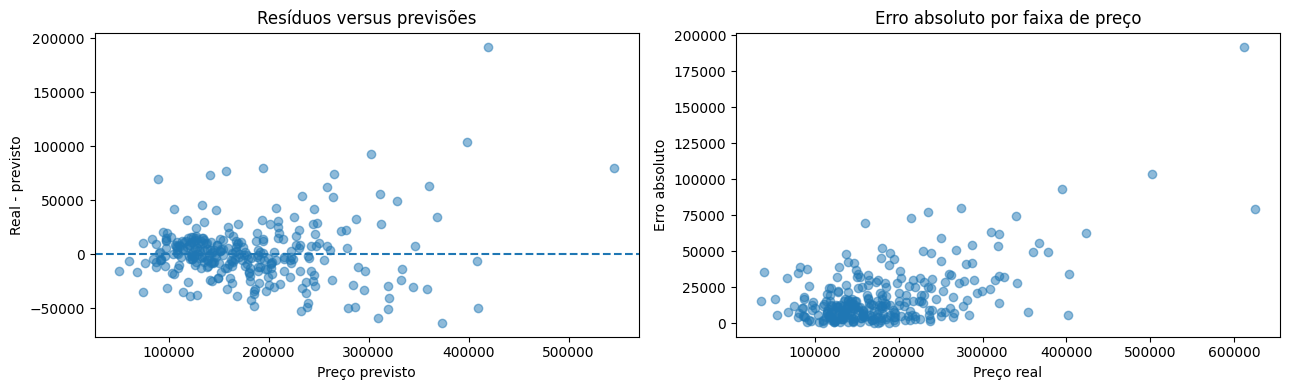

In [49]:
errors = pd.DataFrame({
    "y_real": np.asarray(y_test),
    "y_pred": np.asarray(test_pred),
})
errors["residuo"] = errors["y_real"] - errors["y_pred"]
errors["erro_abs"] = errors["residuo"].abs()
errors["erro_percentual_abs"] = (
    errors["erro_abs"] / errors["y_real"].clip(lower=1)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(errors["y_pred"], errors["residuo"], alpha=0.5)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Preço previsto")
axes[0].set_ylabel("Real - previsto")
axes[0].set_title("Resíduos versus previsões")

axes[1].scatter(errors["y_real"], errors["erro_abs"], alpha=0.5)
axes[1].set_xlabel("Preço real")
axes[1].set_ylabel("Erro absoluto")
axes[1].set_title("Erro absoluto por faixa de preço")

plt.tight_layout()
plt.show()

Reavaliar melhor o tratamento de resíduos com base no capítulo 3 - Regressão Linear do ISLP

In [50]:
price_group = pd.qcut(errors["y_real"], q=5, duplicates="drop")

error_by_price = (
    errors.assign(faixa_preco=price_group)
    .groupby("faixa_preco", observed=True)
    .agg(
        n=("erro_abs", "size"),
        MAE=("erro_abs", "mean"),
        MedianaErro=("erro_abs", "median"),
        ErroPercentualMedio=("erro_percentual_abs", "mean"),
        Vies=("residuo", "mean"),
    )
)

error_by_price

,n,MAE,MedianaErro,ErroPercentualMedio,Vies
faixa_preco,,,,,
"(35310.999, 123300.0]",59,11230.384414,8621.208657,0.133928,-4284.729231
"(123300.0, 147000.0]",59,11793.161966,9352.322193,0.086777,-1441.960827
"(147000.0, 179240.0]",57,14131.890195,10351.736188,0.087649,-1435.641251
"(179240.0, 230000.0]",59,17379.617903,13664.864167,0.086248,-3049.086074
"(230000.0, 625000.0]",58,36411.113281,29455.443179,0.113013,16659.328358


In [51]:
worst_positions = np.argsort(errors["erro_abs"].to_numpy())[-10:][::-1]

worst_cases = X_test.iloc[worst_positions].copy()
worst_cases["SalePrice_real"] = y_test.iloc[worst_positions].to_numpy()
worst_cases["SalePrice_previsto"] = test_pred[worst_positions]
worst_cases["erro_absoluto"] = np.abs(
    worst_cases["SalePrice_real"] - worst_cases["SalePrice_previsto"]
)

display_columns = [
    c for c in [
        "Neighborhood",
        "OverallQual",
        "GrLivArea",
        "YearBuilt",
        "SalePrice_real",
        "SalePrice_previsto",
        "erro_absoluto",
    ]
    if c in worst_cases.columns
]

worst_cases[display_columns]

,Neighborhood,OverallQual,GrLivArea,YearBuilt,SalePrice_real,SalePrice_previsto,erro_absoluto
898,NridgHt,9,2364,2009,611657,419525.188775,192131.811225
178,StoneBr,9,2234,2008,501837,398137.270155,103699.729845
774,NridgHt,8,1973,2006,395000,301986.888239,93013.111761
1107,Gilbert,7,2021,2006,274725,194545.769282,80179.230718
1169,NoRidge,10,3627,1995,625000,545446.224048,79553.775952
1168,Edwards,6,2108,1935,235000,157711.050814,77288.949186
377,Somerst,8,2466,2004,340000,265569.394267,74430.605733
328,BrkSide,6,2134,1916,214500,141612.310049,72887.689951
681,SWISU,5,1520,1932,159434,89837.940859,69596.059141
1442,Somerst,10,2007,2008,310000,373574.089583,63574.089583


### Perguntas para a análise de erros

<details>
<summary><strong>O modelo subestima sistematicamente os imóveis mais caros?</strong></summary>

Observe o viés por quintil e o gráfico de resíduos. Regularização e transformação logarítmica podem comprimir extremos. Se o viés crescer nas faixas altas, o modelo pode precisar de interações, não linearidade ou segmentação.

</details>

<details>
<summary><strong>Os maiores erros são dados ruins?</strong></summary>

Talvez, mas não assuma. Eles podem representar casas raras que exigem atributos ausentes do conjunto. A investigação deve consultar registros originais e conhecimento de domínio.

</details>

# 18. Interpretação do modelo final

Para modelos lineares regularizados, podemos examinar coeficientes transformados. Também usaremos importância por permutação no teste, que mede a perda de desempenho ao embaralhar uma variável original.

A importância por permutação não é causal e pode dividir importância entre variáveis correlacionadas.

In [52]:
if hasattr(final_model, "best_estimator_"):
    fitted_for_perm = final_model.best_estimator_
else:
    fitted_for_perm = final_model

perm = permutation_importance(
    fitted_for_perm,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10 if FAST_MODE else 30,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

perm_table = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_table.head(20)

,feature,importance_mean,importance_std
16,OverallQual,7781.907774,1265.322240
11,Neighborhood,7712.137464,1280.489147
45,GrLivArea,6524.076646,995.163573
60,GarageCars,4971.545283,985.688347
42,1stFlrSF,4872.959133,571.228311
77,SaleType,3544.020968,588.483080
3,LotArea,2993.288537,1122.163610
0,MSSubClass,2553.184738,597.286294
23,Exterior2nd,2045.396927,766.107419
52,KitchenQual,1910.593429,280.780362


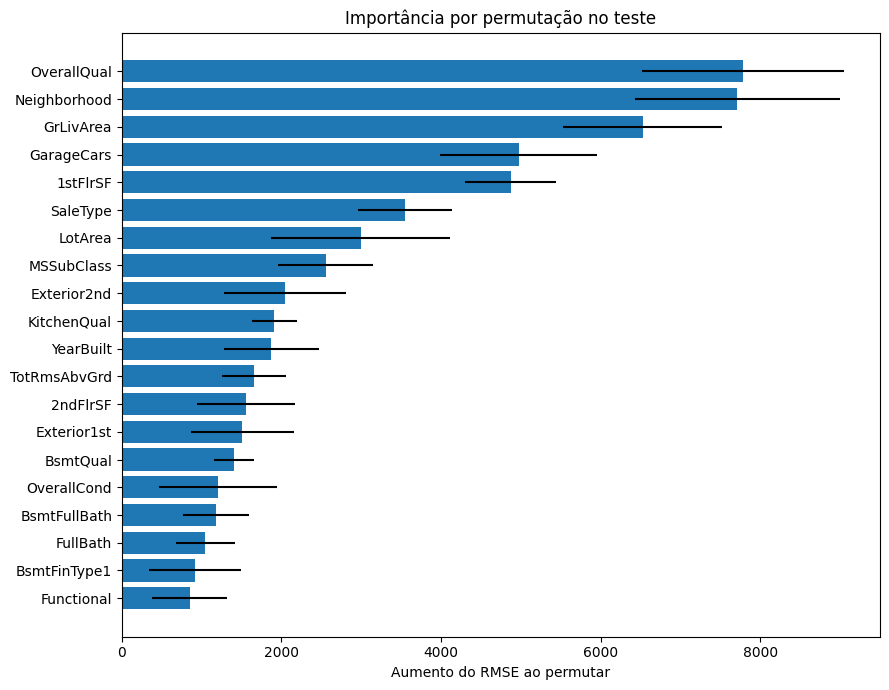

In [53]:
top_perm = perm_table.head(20).sort_values("importance_mean")

plt.figure(figsize=(9, 7))
plt.barh(
    top_perm["feature"],
    top_perm["importance_mean"],
    xerr=top_perm["importance_std"],
)
plt.xlabel("Aumento do RMSE ao permutar")
plt.title("Importância por permutação no teste")
plt.tight_layout()
plt.show()

### Limite importante

O teste foi usado aqui para diagnóstico interpretativo depois da avaliação final. Não use esse ranking para voltar e redesenhar o modelo mantendo o mesmo teste como prova final. Isso iniciaria uma nova rodada de desenvolvimento e exigiria nova validação externa.

# 19. Cartão do modelo

Preencha após executar o notebook.

| Item | Registro |
|---|---|
| Objetivo | Estimar preço de venda residencial |
| População | Vendas presentes no conjunto Ames |
| Resposta | `SalePrice` |
| Modelo escolhido | Ver célula de seleção final |
| Métrica principal | RMSE |
| Métricas auxiliares | MAE, RMSLE, $R^2$ |
| Avaliação interna | Validação cruzada aninhada |
| Avaliação externa | Holdout de 20% |
| Transformação da resposta | $\log(1+y)$ |
| Tratamento numérico | Mediana, indicador de ausência, padronização |
| Tratamento categórico | Moda e one-hot |
| Limitações | Dados históricos e geograficamente específicos |
| Uso proibido | Avaliação automática sem revisão humana |
| Monitoramento necessário | Erro por período, faixa de preço e localização |

# 20. Questões de aprendizagem

## Questão 1, seleção e avaliação

Você aplicou seleção forward no conjunto completo e depois executou 10-fold CV apenas no modelo selecionado. O erro está correto?

<details>
<summary><strong>Resposta</strong></summary>

Não completamente. A seleção viu todas as observações, incluindo aquelas que depois aparecem nas dobras de validação. O processo de seleção precisa ocorrer dentro de cada dobra, ou a avaliação final precisa usar um teste externo ainda intocado.

</details>

## Questão 2, ridge versus lasso

Duas variáveis medem quase a mesma característica. O que você espera de ridge e lasso?

<details>
<summary><strong>Resposta</strong></summary>

Ridge tende a distribuir coeficientes entre as variáveis correlacionadas. Lasso pode escolher uma delas e zerar a outra, com instabilidade na identidade da escolhida. Elastic net tende a manter grupos correlacionados com mais estabilidade.

</details>

## Questão 3, PCA

Um componente explica muita variância dos preditores, mas tem baixa associação com preço. PCR deve mantê-lo?

<details>
<summary><strong>Resposta</strong></summary>

PCR ordena componentes pela variância de $X$, então ele tende a mantê-lo antes de componentes de menor variância, mesmo que estes sejam mais úteis para $Y$. Essa é uma limitação central do PCR.

</details>

## Questão 4, bootstrap

Um coeficiente tem média positiva, mas o intervalo bootstrap atravessa zero. Como relatar?

<details>
<summary><strong>Resposta</strong></summary>

A direção não é estável sob reamostragem. O coeficiente pode ter utilidade conjunta no modelo, mas uma interpretação substantiva isolada deve ser evitada.

</details>

## Questão 5, curva de validação plana

O melhor $\alpha$ é 0,01, mas valores entre 0,01 e 1 têm erros quase iguais. Qual escolher?

<details>
<summary><strong>Resposta</strong></summary>

Uma escolha mais regularizada dentro de um erro-padrão do mínimo pode ser preferível. Ela reduz flexibilidade e costuma aumentar estabilidade sem perda demonstrável de desempenho.

</details>

## Questão 6, desempenho final

O teste ficou melhor que a validação cruzada. Isso prova que o modelo melhorou?

<details>
<summary><strong>Resposta</strong></summary>

Não. O teste é uma amostra finita e pode ser mais fácil por acaso. A diferença deve ser interpretada junto à incerteza e às diferenças de distribuição.

</details>

# 21. Extensões propostas

## Exercício A, custo assimétrico

Crie uma métrica em que superestimar o preço custe 1,5 vez mais que subestimar. Refaça a comparação dos modelos.

## Exercício B, validação temporal

Se houver uma variável de ano da venda, separe treino e teste em ordem temporal. Compare com a divisão aleatória.

## Exercício C, ausência semântica

Substitua a imputação genérica de variáveis como piscina, garagem e porão por categorias que representem ausência estrutural.

## Exercício D, estabilidade da seleção forward

Repita a seleção forward em 100 amostras bootstrap. Calcule a frequência de entrada de cada variável e a distribuição de sua posição no caminho.

## Exercício E, curva de aprendizagem

Meça treino e validação para amostras crescentes. Diagnostique se o modelo se beneficiaria mais de novos dados ou de maior flexibilidade.

## Exercício F, regra de um erro-padrão no lasso

Implemente a escolha do maior $\alpha$ cujo RMSE esteja dentro de um erro-padrão do mínimo. Compare a quantidade de coeficientes não nulos.

In [54]:
# Espaço para o Exercício A

def asymmetric_absolute_error(y_true, y_pred, overprediction_cost=1.5):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    error = y_pred - y_true
    weights = np.where(error > 0, overprediction_cost, 1.0)

    return np.mean(weights * np.abs(error))

# Exemplo:
# asymmetric_absolute_error(y_test, test_pred)

# 22. Persistência

A célula abaixo salva o modelo final e os metadados básicos. O artefato só deve ser usado junto com a versão das bibliotecas e o contrato dos dados.

In [55]:
from joblib import dump

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

dump(final_model, ARTIFACT_DIR / "ames_linear_model.joblib")

metadata = {
    "model_name": best_name,
    "random_state": RANDOM_STATE,
    "sklearn_version": sklearn_version,
    "test_metrics": test_metrics,
    "features_received": list(X_train.columns),
}

pd.Series(metadata).to_json(
    ARTIFACT_DIR / "ames_linear_model_metadata.json",
    force_ascii=False,
    indent=2,
)

print("Artefatos salvos em:", ARTIFACT_DIR.resolve())

Artefatos salvos em: C:\Users\daler\OneDrive\Documentos\python-scripts\ISLP\artifacts


# 23. Referências e trilhas de estudo

## Fontes estruturais do notebook

- James, Witten, Hastie, Tibshirani e Taylor. *An Introduction to Statistical Learning with Applications in Python*, Capítulos 5 e 6.
- Laboratório do Capítulo 5: [Cross-Validation and the Bootstrap](https://github.com/intro-stat-learning/ISLP_labs/blob/stable/Ch05-resample-lab.ipynb)
- Laboratório do Capítulo 6: [Linear Models and Regularization Methods](https://github.com/intro-stat-learning/ISLP_labs/blob/stable/Ch06-varselect-lab.ipynb)
- Scikit-learn MOOC: [índice do curso](https://inria.github.io/scikit-learn-mooc/toc.html)
- Aurélien Géron: [End-to-End Machine Learning Project](https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb)
- OpenML: [House Prices, data id 42165](https://www.openml.org/d/42165)
- Scikit-learn: [exemplo com Ames e transformação da resposta](https://scikit-learn.org/stable/auto_examples/compose/plot_transformed_target.html)
- Scikit-learn MOOC: [avaliação por validação cruzada](https://inria.github.io/scikit-learn-mooc/python_scripts/02_numerical_pipeline_cross_validation.html)
- Scikit-learn MOOC: [regularização de regressão linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_models_regularization.html)
- Scikit-learn MOOC: [validação cruzada aninhada](https://inria.github.io/scikit-learn-mooc/python_scripts/cross_validation_nested.html)

## Leituras complementares em português

- Kevin A. S. Rodrigues, USP: [LASSO Clássico e Bayesiano](https://www.ime.usp.br/~kevinx/LASSO_Texto.pdf)
- Laerte Sodré Jr., IAG-USP: [Regressão e Classificação](https://www.astro.iag.usp.br/~laerte/aga0505_25/aula9.pdf)
- Paulo Ricardo B. Guimarães, UFPR: [Análise de Regressão](https://docs.ufpr.br/~jomarc/regressao.pdf)

## Princípios que devem permanecer

1. O teste não participa do desenvolvimento.
2. Todo pré-processamento é aprendido dentro do treino.
3. Hiperparâmetros são escolhidos por reamostragem.
4. Desempenho precisa de incerteza, não apenas uma média.
5. Seleção preditiva não autoriza interpretação causal.
6. Um modelo mais simples é preferível quando o ganho do complexo não é demonstrável.